In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load goalscorers data
scorers = pd.read_csv('goalscorers.csv')
results = pd.read_csv("/content/results.csv")
former_names = pd.read_csv("/content/former_names.csv")

In [ ]:
#formatting the date
scorers['date'] = pd.to_datetime(scorers['date'])
scorers['year'] = scorers['date'].dt.year
results['date'] = pd.to_datetime(results['date'])

#Remove Duplicates
results.drop_duplicates(inplace=True)

# Create a mapping dictionary from the former_names file
name_mapping = dict(zip(former_names['former'], former_names['current']))

# Update the names in the main results file
results['home_team'] = results['home_team'].replace(name_mapping)
results['away_team'] = results['away_team'].replace(name_mapping)

# **Choosing the player for analysis**

In [ ]:
# Checking  how many goals are recorded for a specific player

player_name = 'Lionel Messi'
goal_count = scorers[scorers['scorer'] == player_name].shape[0]

print(player_name," has", goal_count,"goals in the dataset")

Lionel Messi  has 63 goals in the dataset


# **Filter for Lionel Messi**

In [ ]:
# Filter for Lionel Messi
messi_df = scorers[scorers['scorer'] == 'Lionel Messi'].copy()

# **UNIVARIATE ANALYSIS on Lionel Messi**

To see when Messi scores most of his goals.

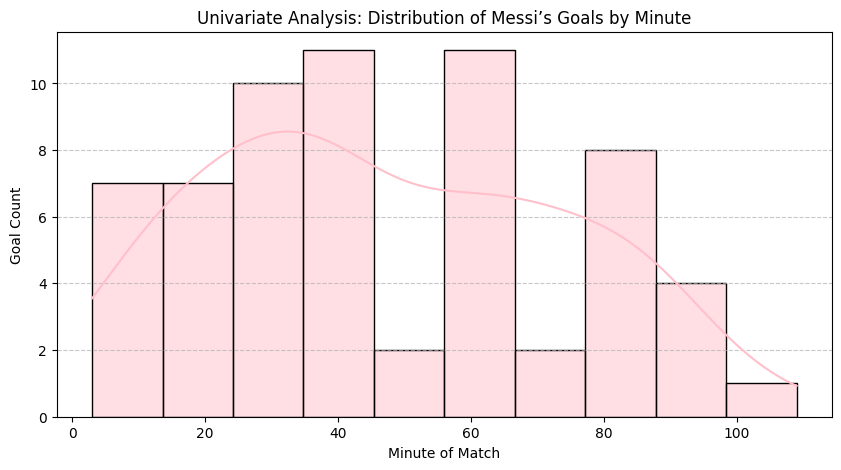

In [ ]:
# --- UNIVARIATE ANALYSIS: Goal Timing ---
plt.figure(figsize=(10, 5))
sns.histplot(messi_df['minute'], bins=10, kde=True, color='pink')
plt.title('Univariate Analysis: Distribution of Messi’s Goals by Minute')
plt.xlabel('Minute of Match')
plt.ylabel('Goal Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# **BIVARIATE ANALYSIS on Lionel Messi**

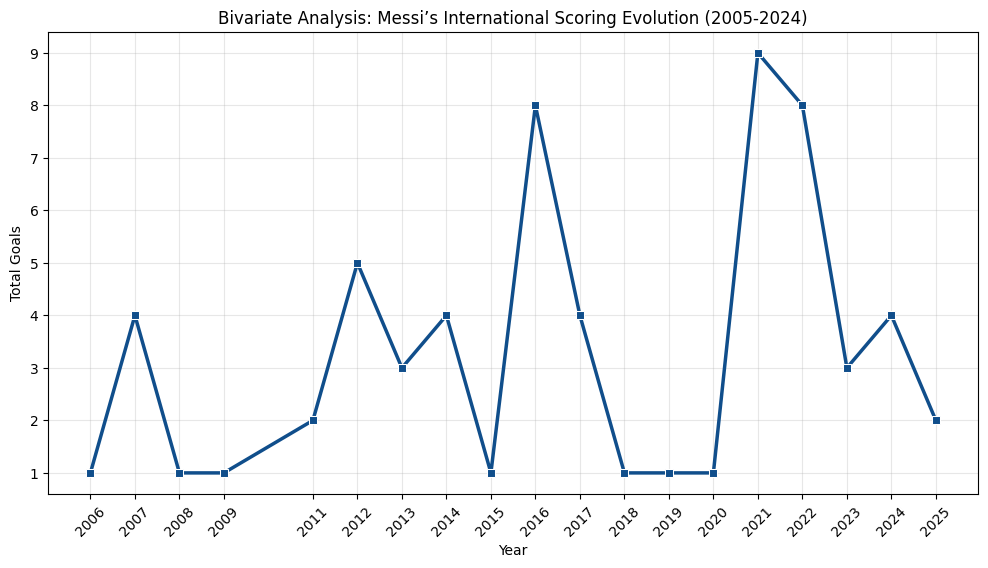

In [ ]:
# --- BIVARIATE ANALYSIS: Evolution Over Time ---
plt.figure(figsize=(12, 6))
messi_annual = messi_df.groupby('year').size().reset_index(name='goals')
sns.lineplot(data=messi_annual, x='year', y='goals', marker='s', color='#104E8B', linewidth=2.5)
plt.title('Bivariate Analysis: Messi’s International Scoring Evolution (2005-2024)')
plt.xlabel('Year')
plt.ylabel('Total Goals')
plt.xticks(messi_annual['year'], rotation=45)
plt.grid(True, alpha=0.3)
plt.show()
